In [111]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots, metrics
from neuralhydrology.nh_run import start_run, eval_run

In [112]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP02_no_sw_transfer_1yrtr_2yrval'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

### Evaluate run on test set
Change the `run_dir` argument by grabbing from:
1. above training output log
2. below list of runs

In [113]:
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()
exp_runs

['EXP02_no_sw_transfer_1yrtr_2yrval_2808_131713',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_132603',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_132611',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_133040',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_133218',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_134312',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_134407',
 'EXP02_no_sw_transfer_1yrtr_2yrval_2808_134545']

In [114]:
exp_count = eval_wrapper.check_exp_count(exp_runs)

EXP02_no_sw_transfer_1yrtr_2yrval :	 8


In [115]:
train_results = [None] * len(exp_runs)
test_results = [None] * len(exp_runs)
for idx,run in enumerate(exp_runs):
    train_results[idx] , test_results[idx] = eval_wrapper.quick_single_eval(run, all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_1yrtr_2yrval_2808_131713
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_1yrtr_2yrval_2808_131713
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_1yrtr_2yrval_2808_132603
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_transfer_1yrtr_2yrval_2808_132603
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP02_no_sw_trans

In [116]:
def ensemble_mean_std(ensemble_df):
    average = ensemble_df.mean(axis=1).to_frame(name='mean')
    average['std'] = ensemble_df.std(axis=1)
    return average

In [117]:
def Qobs_by_basin(results_list):
    all_basin_keys = list(results_list[0].keys())
    print(all_basin_keys)

    Qobs_by_basin = {}
    for basin_key in all_basin_keys:
        Qobs_by_basin[basin_key] = pd.concat([result[basin_key]['1D']['xr']['Q_obs'].to_pandas() for result in results_list],axis=1)
    return Qobs_by_basin

In [118]:
def Qsims_by_basin(results_list):
    all_basin_keys = list(results_list[0].keys())
    print(all_basin_keys)

    Qsims_by_basin = {}
    for basin_key in all_basin_keys:
        Qsims_by_basin[basin_key] = pd.concat([result[basin_key]['1D']['xr']['Q_sim'].to_pandas() for result in results_list],axis=1)
    return Qsims_by_basin

In [119]:
def ensemble_aggregation(results_list):
    all_Qobs = Qobs_by_basin(results_list)
    Qobs_mean = {key:ensemble_mean_std(all_Qobs[key]) for key in all_Qobs}

    all_Qsims = Qsims_by_basin(results_list)
    Qsim_mean = {key:ensemble_mean_std(all_Qsims[key]) for key in all_Qsims}

    nh_dict = {key:ensemble_df_to_nh_dict(Qobs_mean[key] , Qsim_mean[key]) for key in Qsim_mean}

    return nh_dict

In [154]:
def ensemble_df_to_nh_dict(Qobs_df,Qsim_df):
    Qsim_xr = xr.Dataset.from_dataframe(Qsim_df.add_prefix('Qsim_'))
    Qobs_xr = xr.Dataset.from_dataframe(Qobs_df.add_prefix('Qobs_'))

    # Formatting to match nh structure
    Q_xr = xr.merge([Qsim_xr,Qobs_xr]).assign_coords({"time_step":0}).expand_dims("time_step").transpose()
    Q_xr = Q_xr.rename_vars({'Qsim_mean':'Q_sim','Qobs_mean':'Q_obs'})
    
    nse = metrics.nse(Q_xr['Q_obs'].isel(time_step=0),Q_xr['Q_sim'].isel(time_step=0))
    nh_dict = {'1D':{'xr':Q_xr,'NSE':nse}}
    return nh_dict

In [155]:
train_ensemble = ensemble_aggregation(train_results)
test_ensemble = ensemble_aggregation(test_results)

['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096']
['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096']
['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096']
['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096']


In [ ]:
ax = Qsim_test['1159302']['mean'].plot()
ax.fill_between(Qsim_test['1159302']['mean'].index, Qsim_test['1159302']['mean'] - Qsim_test['1159302']['std'],Qsim_test['1159302']['mean'] + Qsim_test['1159302']['std'],alpha=0.5)

In [ ]:
train_ensemble['1159302']['1D']

{'NSE': -6.8510674211581675,
 'MSE': 4867.58984375,
 'RMSE': np.float64(69.76811480719542),
 'KGE': np.float64(-0.9462939040639569),
 'Alpha-NSE': 0.1865813228820276,
 'Beta-KGE': 0.10750921981616912,
 'Beta-NSE': -2.5729020206176028,
 'Pearson-r': -0.526391327381134,
 'FHV': np.float32(-85.352394),
 'FMS': np.float32(76.921875),
 'FLV': np.float32(-4452.2725),
 'Peak-Timing': np.float64(2.5),
 'Peak-MAPE': np.float32(92.331184)}

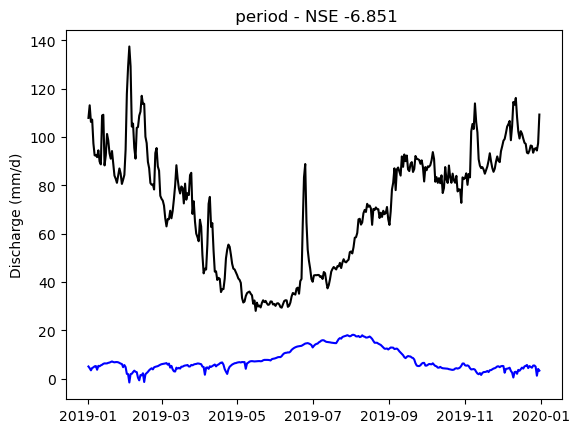

In [156]:
fig, ax = plt.subplots()
comp_plots.plot_obs_sim_timeseries(ax,train_ensemble['1159302']['1D'])

In [ ]:
train_all_ts['3103450'].mean(axis=1)
train_all_ts['3103450'].std(axis=1)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10),sharey=True)
tr2_1_nse_df = comp_plots.boxplot_from_tuple(results_tuple_2_1,ax=axs[0],tuple_names=default_order,exp_name = '2yr_1yr')
tr1_2_nse_df = comp_plots.boxplot_from_tuple(results_tuple_1_2,ax=axs[1],tuple_names=default_order,exp_name = '1yr_2yr')
axs[0].set_ylim([-10,1])

In [ ]:
tr10_1_nse_df

In [ ]:
tr9_2_nse_df